In [2]:
## IMPORT 
import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd

sys.path.append('..')

from cross_val_data import cross_validation
from data_loader import get_data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = get_data()
print('X_tr:', X_train.shape, 'X_te:', X_test.shape)

X_tr: (48000, 784) X_te: (10000, 784)


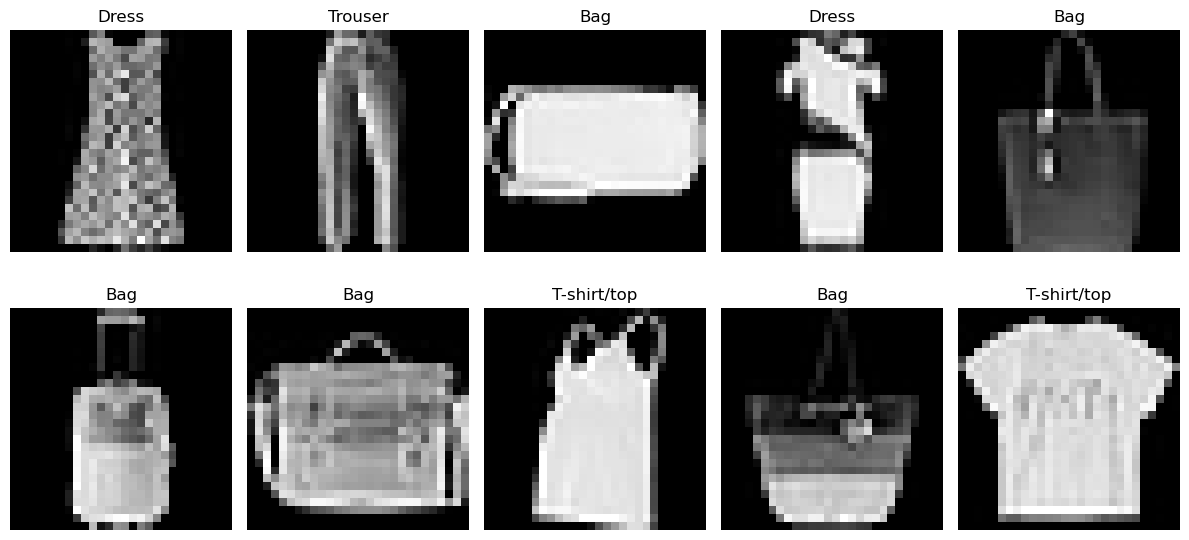

In [5]:
## Data Visualization

# Fashion-MNIST class names (label 0-9 maps to these)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Show the first 10 images in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# Scaling X 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform
X_val_scaled = scaler.transform(X_val)           # transform only
X_test_scaled = scaler.transform(X_test)         # transform only

In [7]:
X_train_scaled.shape

(48000, 784)

In [8]:
# Baseline Model
model = LogisticRegression(max_iter=2000, random_state=101)
model.fit(X_train_scaled, y_train)

# Accuracy
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, model.predict(X_val_scaled))

print(f"Baseline Model train accuracy: {train_acc:.4f}")
print(f"Baseline  Model val accuracy:   {val_acc:.4f}")

Baseline Model train accuracy: 0.8929
Baseline  Model val accuracy:   0.8404


In [15]:
# Tuning hyperparameter
param_grid = {
    'C': np.logspace(-3, 2, 6)
}
clf = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=101),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

clf.fit(X_train_scaled, y_train)

results = pd.DataFrame(clf.cv_results_)
print(results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
         params  mean_test_score  std_test_score  rank_test_score
1   {'C': 0.01}         0.856417        0.002817                1
0  {'C': 0.001}         0.850812        0.003286                2
2    {'C': 0.1}         0.848312        0.002084                3
3    {'C': 1.0}         0.839146        0.002620                4
4   {'C': 10.0}         0.830188        0.002955                5
5  {'C': 100.0}         0.827500        0.003715                6


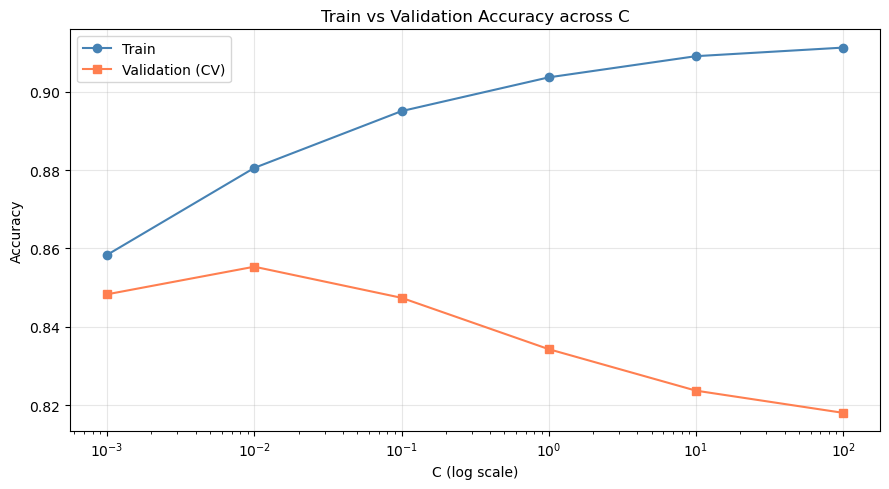

In [10]:
results = pd.DataFrame(clf.cv_results_)

plt.figure(figsize=(9, 5))
plt.semilogx(results['param_C'], results['mean_train_score'], 'o-', label='Train', color='steelblue')
plt.semilogx(results['param_C'], results['mean_test_score'], 's-', label='Validation (CV)', color='coral')

plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy across C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Final model = the best estimator from GridSearchCV
final_model = clf.best_estimator_

# Evaluate on test set
y_test_pred = final_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Test accuracy: {test_acc:.4f}\n")

Test accuracy: 0.8450



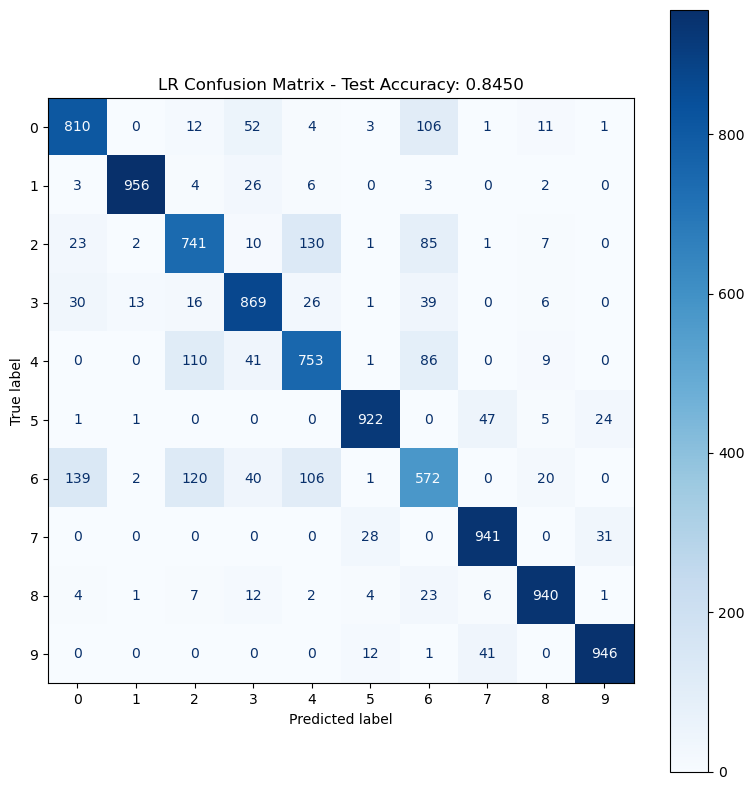

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title(f'LR Confusion Matrix - Test Accuracy: {test_acc:.4f}')
plt.tight_layout()
plt.show()

In [14]:
tr_folds, val_folds = cross_validation()

best_C = clf.best_params_['C']
print(f"Cross-validating LogisticRegression with C = {best_C}\n")

cv_scores = []
for i in range(len(tr_folds)):
    X_tr, y_tr = tr_folds[i]
    X_va, y_va = val_folds[i]

    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr)
    X_va_scaled = fold_scaler.transform(X_va)

    fold_model = LogisticRegression(C=best_C, max_iter=2000, random_state=101)
    fold_model.fit(X_tr_scaled, y_tr)

    acc = accuracy_score(y_va, fold_model.predict(X_va_scaled))
    cv_scores.append(acc)
    print(f"Fold {i+1} accuracy: {acc:.4f}")

cv_scores = np.array(cv_scores)
print(f"\nMean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std  CV accuracy: {cv_scores.std():.4f}")

Cross-validating LogisticRegression with C = 0.01

Fold 1 accuracy: 0.8568
Fold 2 accuracy: 0.8561
Fold 3 accuracy: 0.8589
Fold 4 accuracy: 0.8577
Fold 5 accuracy: 0.8584

Mean CV accuracy: 0.8576
Std  CV accuracy: 0.0010
